<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_TP4/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_4_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TP4 - Aprendizaje no supervisado

In [13]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time
import warnings
from scipy.stats import norm, ks_2samp
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#Ejercicio 2 - Detección de fraude en transacciones bancarias

>Una fintech que opera un sistema de pagos automatizado con tarjetas de crédito procesa en promedio
300.000 transacciones diarias. El sistema aprueba las operaciones en tiempo real: una demora de más de
2 segundos en la decisión es inaceptable desde el punto de vista de experiencia del usuario.
El equipo de riesgo realizó hace varios meses un estudio interno sobre una muestra de transacciones y
determinó que menos del 0,2 % corresponden a operaciones fraudulentas o sospechosas. Sin embargo,
ese estudio tiene limitaciones metodológicas que no son del todo claras, y el equipo no confía
completamente en ese porcentaje. Las operaciones sospechosas deberían retenerse para revisión manual
antes de ser aprobadas, pero el costo de retener una operación legítima (cliente insatisfecho, fricción)
también es real.
El dataset [2] (creditcard.csv) contiene más de 280.000 transacciones con las siguientes variables: Time
(segundos desde la primera transacción del conjunto), V1 a V28 (características de la operación,
probablemente resultado de una reducción de dimensionalidad previa por razones de confidencialidad),
y Amount (monto de la transacción). No se proveen etiquetas de fraude: el ejercicio consiste en encontrar
las anomalías de forma no supervisada.



---


## 0. Configuración del entorno

In [14]:
# Dataset desde el repositorio en Drive
# A partir de cierto tamaño, no se puede descargar directo con wget

import gdown
file_id = "1Zy1fV1U5nXj8XXhcqEI4YjEmlzbodk0n"
output_file = "creditcard.zip"

if not os.path.exists(output_file):
    gdown.download(f"https://drive.google.com/uc?id={file_id}", output_file)
    !unzip creditcard.zip

df_fraude = pd.read_csv("creditcard.csv")
# El dataset real tiene columna 'Class'; la removemos para el ejercicio no supervisado
# pero la guardamos para evaluación posterior si existe
if "Class" in df_fraude.columns:
    TRUE_LABELS = df_fraude["Class"].copy()
    df_fraude.drop(columns=["Class"], inplace=True)
    HAS_TRUE_LABELS = True
    print(f"Dataset real cargado: {df_fraude.shape[0]:,} filas × {df_fraude.shape[1]} columnas")
    print(f"Etiquetas reales disponibles para evaluación (no usadas en modelado)")

Dataset real cargado: 284,807 filas × 30 columnas
Etiquetas reales disponibles para evaluación (no usadas en modelado)




---


##1. EDA

### 1.1 Vistazo inicial

Comenzamos dando una pequeña vista a algunas entradas de nuestro dataset.

Entre las variables contamos con `Time` y `Amount` por un lado y las variables `V1 - V28`, siendo estas ultimas resultado de una reduccion de dimensionalidad previa.

In [15]:

# Resumen general
print("=" * 60)
print("RESUMEN GENERAL DEL DATASET")
print("=" * 60)
print(f"Dimensiones        : {df_fraude.shape[0]:,} filas × {df_fraude.shape[1]} columnas")
print(f"Memoria estimada   : {df_fraude.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Valores faltantes  : {df_fraude.isnull().sum().sum()}")
print()
display(df_fraude.head())


RESUMEN GENERAL DEL DATASET
Dimensiones        : 284,807 filas × 30 columnas
Memoria estimada   : 68.4 MB
Valores faltantes  : 0



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [16]:
# Verificar si hay valores negativos en 'Time' y 'Amount'
negativos_time = (df_fraude['Time'] < 0).sum()
negativos_amount = (df_fraude['Amount'] < 0).sum()

print(f"Valores negativos en 'Time': {negativos_time}")
print(f"Valores negativos en 'Amount': {negativos_amount}")

if negativos_time == 0 and negativos_amount == 0:
    print("\nNo se encontraron valores negativos en estas columnas.")
else:
    print("\nSe detectaron valores negativos que requieren revisión.")

Valores negativos en 'Time': 0
Valores negativos en 'Amount': 0

No se encontraron valores negativos en estas columnas.


El dataset no presenta valores faltantes o ilógicos, lo que elimina la necesidad de
imputación y descarta que los NaN sean una señal espuria de anomalía.

Las 30 columnas corresponden a Time, V1–V28 y Amount. La columna `Class`
fue removida antes del análisis confirmando que el ejercicio es genuinamente
no supervisado: los modelos no tienen acceso a ninguna etiqueta durante
el entrenamiento.

Con 284.807 filas y 68.4 MB el dataset es manejable en memoria, pero su
tamaño descarta métodos con complejidad cuadrática como One-Class SVM,
cuya matriz de Gram requeriría varios cientos de GB solo para almacenarse.

### 1.2 Estadística descriptiva

La tabla de estadísticas descriptivas se extiende con dos métricas adicionales
que son especialmente relevantes para detección de anomalías: asimetría y curtosis.

**Asimetría (skewness)** indica si la distribución tiene una cola más larga hacia
alguno de los dos lados. Una variable muy sesgada hace que modelos como PCA de
reconstrucción capturen la asimetría como si fuera estructura relevante, cuando
en realidad es una característica distribucional de las transacciones legítimas.

**Curtosis (kurtosis)** mide qué tan pesadas son las colas respecto a una
distribución normal. Una curtosis alta significa más valores extremos de lo
esperado, lo que afecta directamente la calibración del umbral de detección:
si todas las variables tienen colas pesadas, un umbral fijo basado en normalidad
va a generar demasiados falsos positivos.

In [17]:

# Estadísticas descriptivas
desc = df_fraude.describe().T
desc["skewness"] = df_fraude.skew()
desc["kurtosis"] = df_fraude.kurt()
display(desc.round(3))


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Time,284807.0,94813.86,47488.146,0.000,54201.500,84692.000,139320.500,172792.000,-0.036,-1.294
V1,284807.0,0.00,1.959,-56.408,-0.920,0.018,1.316,2.455,-3.281,32.487
V2,284807.0,0.00,1.651,-72.716,-0.599,0.065,0.804,22.058,-4.625,95.773
V3,284807.0,-0.00,1.516,-48.326,-0.890,0.180,1.027,9.383,-2.240,26.620
V4,284807.0,0.00,1.416,-5.683,-0.849,-0.020,0.743,16.875,0.676,2.635
V5,284807.0,0.00,1.380,-113.743,-0.692,-0.054,0.612,34.802,-2.426,206.905
V6,284807.0,0.00,1.332,-26.161,-0.768,-0.274,0.399,73.302,1.827,42.642
V7,284807.0,-0.00,1.237,-43.557,-0.554,0.040,0.570,120.589,2.554,405.607
V8,284807.0,0.00,1.194,-73.217,-0.209,0.022,0.327,20.007,-8.522,220.587
V9,284807.0,-0.00,1.099,-13.434,-0.643,-0.051,0.597,15.595,0.555,3.731


Analizando estos datos, notamos un común denominador en algunas variables, y es su alto valor de curtosis. Una curtosis alta significa que hay más valores extremos de lo esperado.  
En cuanto al sesgo de las variables, la mayoria parecen apuntar a la simetría, siendo la mas sesgada `Amount`.

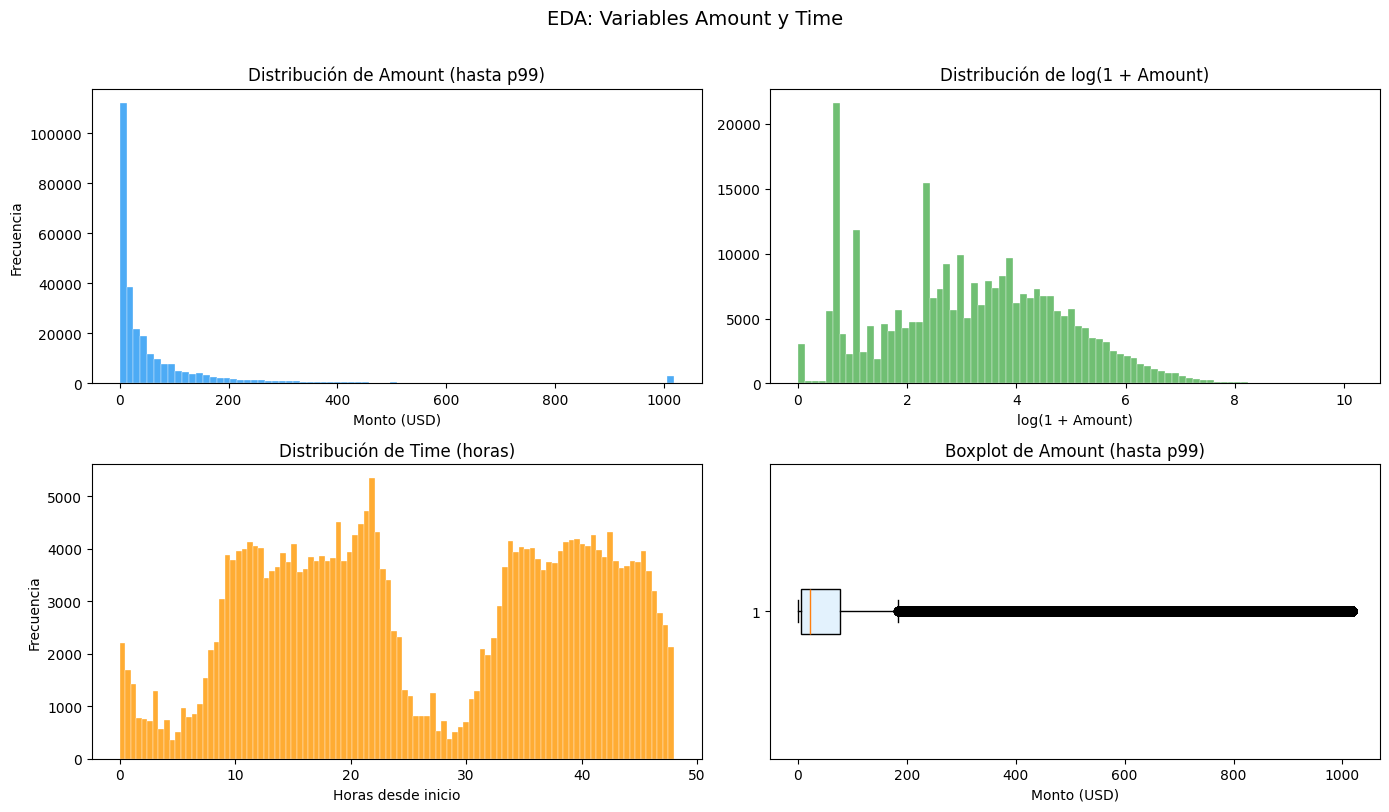

Amount — Mediana: $22.00  |  Media: $88.35
Amount — p95: $365.00  |  p99: $1017.97  |  Máx: $25691.16
Time   — Rango: 0s – 172792s (48.0 horas)


In [18]:

# Distribución de Amount y Time
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Amount
ax = axes[0, 0]
ax.hist(df_fraude["Amount"].clip(upper=df_fraude["Amount"].quantile(0.99)),
        bins=80, color="#2196F3", alpha=0.8, edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de Amount (hasta p99)")
ax.set_xlabel("Monto (USD)")
ax.set_ylabel("Frecuencia")

# Log Amount
ax = axes[0, 1]
ax.hist(np.log1p(df_fraude["Amount"]), bins=80, color="#4CAF50", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de log(1 + Amount)")
ax.set_xlabel("log(1 + Amount)")

# Time
ax = axes[1, 0]
ax.hist(df_fraude["Time"] / 3600, bins=100, color="#FF9800", alpha=0.8,
        edgecolor="white", linewidth=0.3)
ax.set_title("Distribución de Time (horas)")
ax.set_xlabel("Horas desde inicio")
ax.set_ylabel("Frecuencia")

# Boxplot de Amount
ax = axes[1, 1]
data_box = df_fraude["Amount"].clip(upper=df_fraude["Amount"].quantile(0.99))
ax.boxplot(data_box, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#E3F2FD"))
ax.set_title("Boxplot de Amount (hasta p99)")
ax.set_xlabel("Monto (USD)")

plt.suptitle("EDA: Variables Amount y Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Amount — Mediana: ${df_fraude['Amount'].median():.2f}  |  Media: ${df_fraude['Amount'].mean():.2f}")
print(f"Amount — p95: ${df_fraude['Amount'].quantile(0.95):.2f}  |  p99: ${df_fraude['Amount'].quantile(0.99):.2f}  |  Máx: ${df_fraude['Amount'].max():.2f}")
print(f"Time   — Rango: {df_fraude['Time'].min():.0f}s – {df_fraude['Time'].max():.0f}s ({df_fraude['Time'].max()/3600:.1f} horas)")


Aqui podemos ver la distribución real de `Monto` excluyendo el 1% más extremo para que la escala no aplaste el resto, confirmando su alto sesgo positivo.  
Ademas, al aplicar una transformacion logarítmica se produce una distribución aproximadamente simétrica y unimodal, demostrando que sigue una distribución log-normal.

Al mismo tiempo, notamos que en la distribución de `Time` se pueden distinguir dos ciclos de 24 horas, con valles pronunciados en ciertos valores (probablemente altas horas de la noche).  

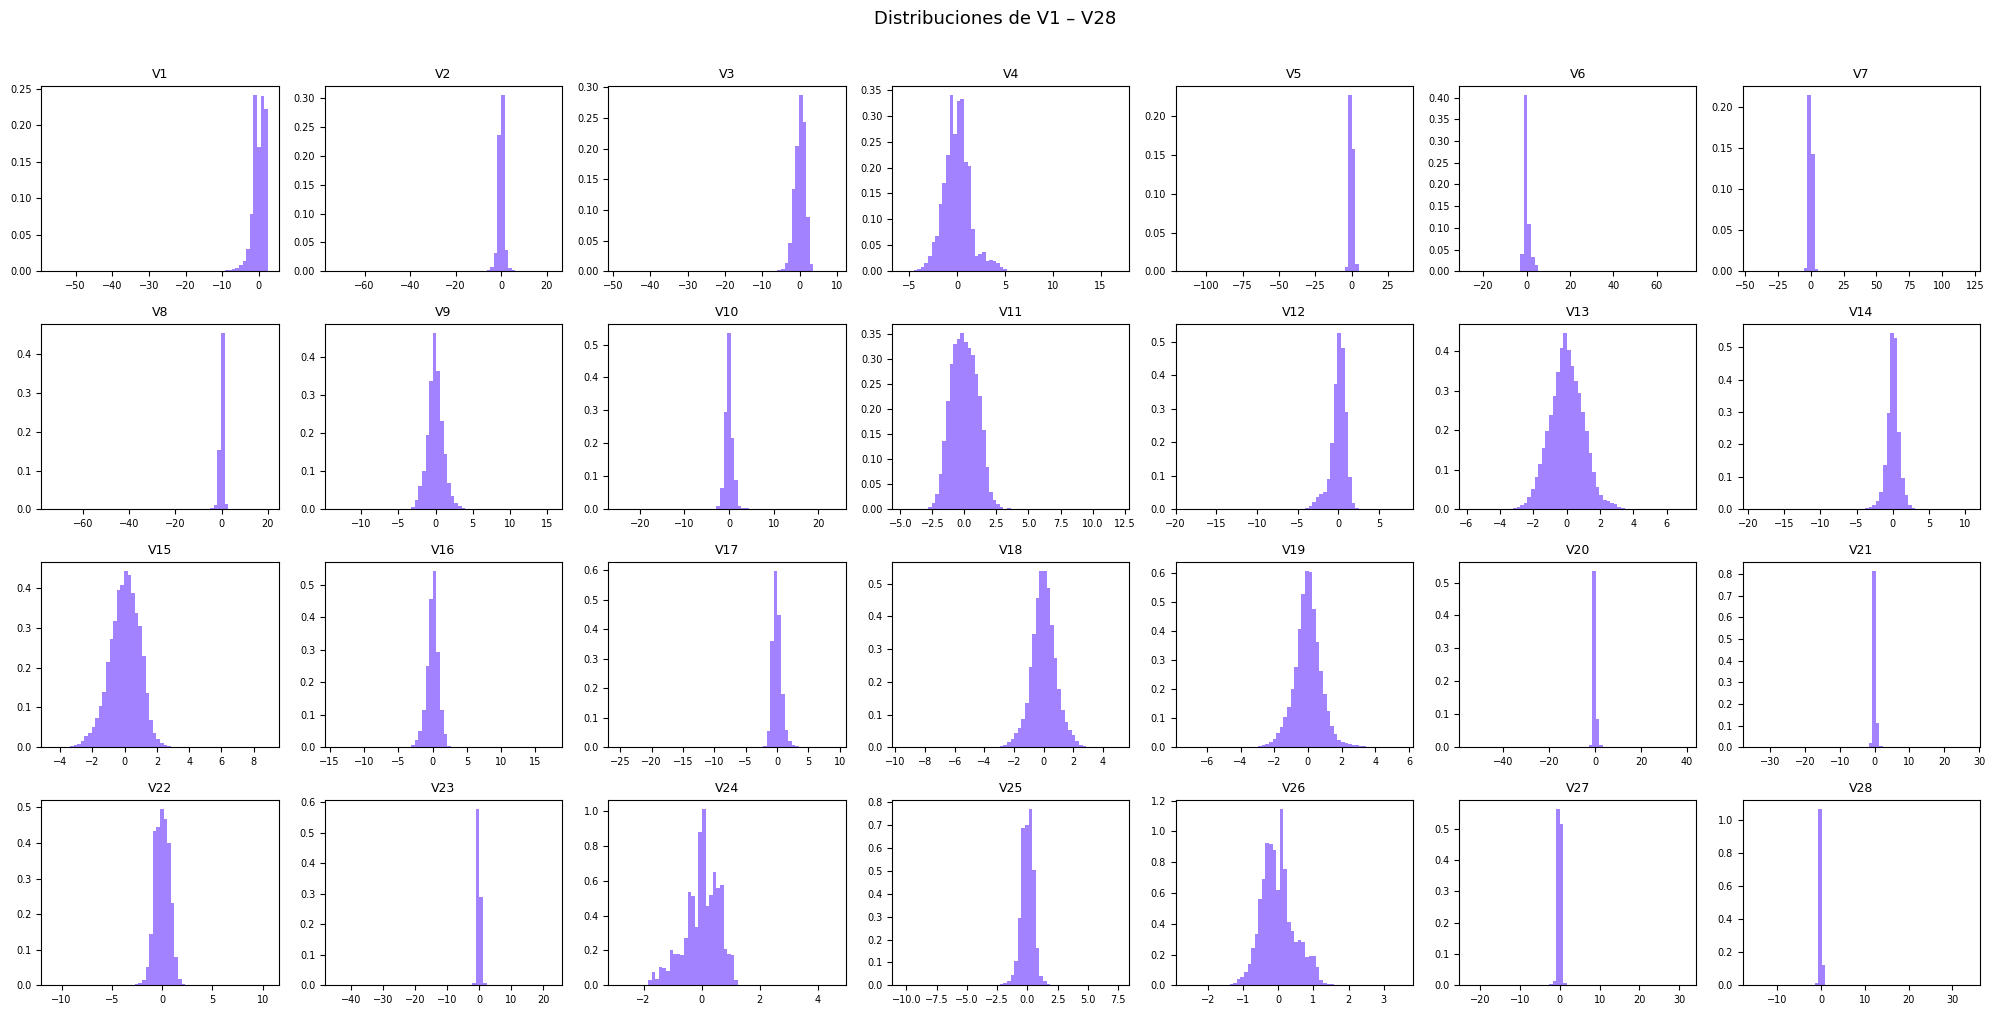


Top 10 variables por asimetría absoluta:


,Variable,Skewness,Kurtosis
0,Amount,16.977724,845.092646
1,V28,11.192091,933.397502
2,V8,-8.521944,220.586974
3,V23,-5.875140,440.088659
4,V2,-4.624866,95.773106
5,V17,-3.844914,94.799719
6,V21,3.592991,207.287040
7,V1,-3.280667,32.486679
8,V7,2.553907,405.607417
9,V5,-2.425901,206.904560


In [19]:
# Distribuciones de variables V1-V28
v_cols = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(4, 7, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    axes[i].hist(df_fraude[col], bins=60, color="#7C4DFF", alpha=0.7,
                 edgecolor="none", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

# Ocultar subplots sobrantes
for j in range(len(v_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuciones de V1 – V28", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Asimetría
skew_df_fraude = pd.DataFrame({
    "Variable": v_cols + ["Amount"],
    "Skewness": [df_fraude[c].skew() for c in v_cols] + [df_fraude["Amount"].skew()],
    "Kurtosis": [df_fraude[c].kurt() for c in v_cols] + [df_fraude["Amount"].kurt()],
}).sort_values("Skewness", key=abs, ascending=False)

print("\nTop 10 variables por asimetría absoluta:")
display(skew_df_fraude.head(10).reset_index(drop=True))

La mayoría de las variables están centradas en cero y tienen forma
aproximadamente simétrica, lo cual es consistente con el PCA previo
y es una buena señal para el modelado.  
Las excepciones son las variables del top de asimetría absoluta, que pueden
distorsionar el modelo de reconstrucción PCA al capturar sus colas como
estructura relevante. Las de curtosis elevada pueden generar falsos positivos
en Isolation Forest al confundir valores extremos legítimos con anomalías.

### 1.3 Correlaciones

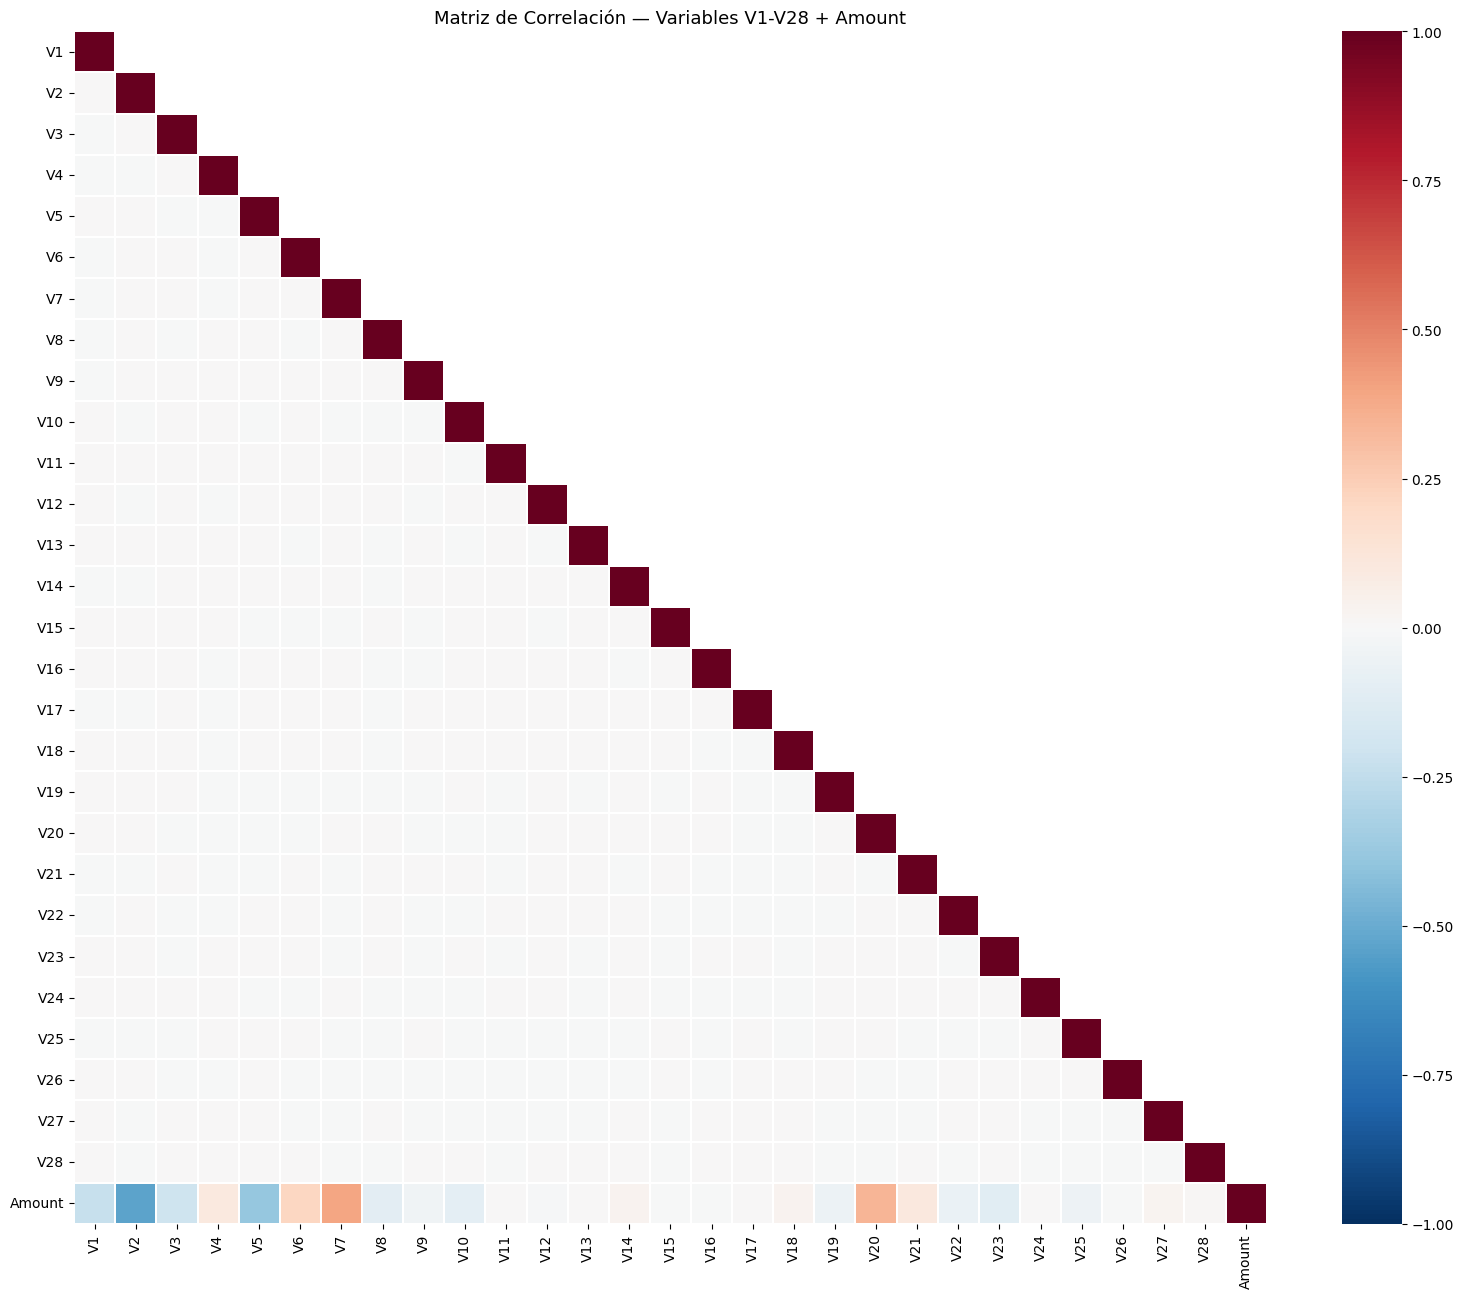

Pares con |correlación| > 0.15:
V2   Amount   -0.531409
V7   Amount    0.397311
V5   Amount   -0.386356
V20  Amount    0.339403
V1   Amount   -0.227709
V6   Amount    0.215981
V3   Amount   -0.210880


In [21]:

# Mapa de correlaciones
fig, ax = plt.subplots(figsize=(16, 13))

corr = df_fraude[v_cols + ["Amount"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.3, linecolor="white",
            annot=False, ax=ax, square=True)

ax.set_title("Matriz de Correlación — Variables V1-V28 + Amount", fontsize=13)
plt.tight_layout()
plt.show()

# Pares más correlacionados
corr_unstacked = corr.where(~np.tril(np.ones(corr.shape, dtype=bool))).stack()
print("Pares con |correlación| > 0.15:")
high_corr = corr_unstacked[corr_unstacked.abs() > 0.15].sort_values(key=abs, ascending=False)
print(high_corr.head(15).to_string())


Las correlaciones entre V1–V28 son cercanas a cero, confirmando que el
PCA previo fue aplicado correctamente y que no hay redundancia entre variables.

Las correlaciones con Amount son en general bajas, lo que indica que el
monto de la transacción no está capturado dominantemente por ninguna
componente individual. Esto es relevante para el modelado: Amount aporta
información independiente de las V y su inclusión como feature adicional
está justificada.

### 1.4 Deteccion de valores extremos

Decidimos utilizar las métricas z-score e IQR para detectar valores extremos porque:

- El z-score es sensible a los propios outliers que intenta detectar, un valor extremo desplaza la media y el desvío, lo que puede tanto inflar como ocultar otros outliers.
- El IQR usa solo la mitad central de los datos como referencia, por lo que es robusto a ese efecto. Usar ambos juntos permite detectar **discrepancias entre métodos**, que son en sí mismas información sobre la forma de cada distribución.

In [22]:

# Detección de outliers univariados (z-score y IQR)
from scipy.stats import zscore

v_cols = [f"V{i}" for i in range(1, 29)]
z_scores = df_fraude[v_cols + ["Amount"]].apply(zscore)
outliers_z = (z_scores.abs() > 3).sum()

q1 = df_fraude[v_cols + ["Amount"]].quantile(0.25)
q3 = df_fraude[v_cols + ["Amount"]].quantile(0.75)
iqr = q3 - q1
outliers_iqr = ((df_fraude[v_cols + ["Amount"]] < (q1 - 3 * iqr)) |
                (df_fraude[v_cols + ["Amount"]] > (q3 + 3 * iqr))).sum()

out_df = pd.DataFrame({
    "Outliers |z| > 3": outliers_z,
    "Outliers IQR×3":   outliers_iqr,
})
out_df["% z-score"] = (out_df["Outliers |z| > 3"] / len(df_fraude) * 100).round(3)
out_df["% IQR"]     = (out_df["Outliers IQR×3"]   / len(df_fraude) * 100).round(3)
print("Outliers univariados por variable:")
display(out_df.sort_values("% z-score", ascending=False).head(15))

Outliers univariados por variable:


,Outliers |z| > 3,Outliers IQR×3,% z-score,% IQR
V27,4771,16524,1.675,5.802
V6,4652,5389,1.633,1.892
V20,4645,13385,1.631,4.700
V2,4318,4453,1.516,1.564
V8,4221,11285,1.482,3.962
Amount,4076,18941,1.431,6.650
V21,4064,6934,1.427,2.435
V1,3701,1994,1.299,0.700
V10,3488,3208,1.225,1.126
V7,3401,3051,1.194,1.071


### Conclusiones del análisis de outliers univariados

**1. Las discrepancias entre métodos son la señal más relevante**  
Variables como V19 (z-score: 1,19% vs IQR: 0,22%) y Amount (z-score: 1,43% vs IQR: 6,65%) muestran diferencias de 5 a 6 veces entre métodos. Esto indica distribuciones fuertemente sesgadas donde el z-score está siendo engañado por la media desplazada. Estas variables requieren transformación (log, RobustScaler) antes del modelado con PCA.

**2. V1 es el caso opuesto**  
Z-score detecta más que IQR (1,30% vs 0,70%), lo que sugiere una distribución
simétrica pero con colas más pesadas que una normal (alta curtosis).
Los outliers de V1 son genuinamente extremos en ambas direcciones.

**3. El volumen general no implica fraude**  
Las variables del top tienen entre 1,1% y 1,7% de outliers univariados.
Con 28 variables, casi cualquier transacción sería outlier en alguna variable
por simple probabilidad. Esto confirma que **los outliers univariados no son anomalías**:
son condición necesaria pero no suficiente. El modelado multivariado es imprescindible.



---


##2. Estrategia y preprocesamiento

### 2.1 Selección de estrategias no supervisadas

### Criterios de selección

Con **~280.000 transacciones**, **28 dimensiones** y una tasa de fraude esperada de **< 0,2 %**, los criterios son:

- **Escala computacional:** el algoritmo debe entrenar sobre 280k filas
  en tiempo razonable. Métodos con complejidad O(n²) o superior quedan
  descartados directamente.
- **Latencia de inferencia:** el sistema debe decidir en menos de 2 segundos
  por transacción. El costo de entrenamiento es tolerable; el de predicción, no.
- **Desbalance extremo:** con menos del 0,2% de anomalías, los métodos que
  asumen clases balanceadas o que dependen de clusters bien definidos
  pierden capacidad discriminativa.
- **Supuestos distribucionales:** algunos métodos asumen normalidad o
  frontera hiperesferal. Dado lo que vimos en el EDA, esos supuestos
  no se sostienen en este dataset.

### Métodos evaluados

| Método | Escala | Supuesto clave | Viable en prod | Decisión |
|---|---|---|---|---|
| **Isolation Forest** | ✅ O(n log n) | Anomalías son pocas y distintas | ✅ | Incluido |
| **LOF** | ⚠️ O(n²) sin aprox. | Densidad local comparable | ⚠️ Solo batch | Incluido |
| **PCA Reconstruction** | ✅ O(n·k·d) | Varianza = comportamiento normal | ✅ | Incluido |
| **One-Class SVM** | ❌ O(n²–n³) | Frontera hiperesferal | ❌ | Descartado |
| **DBSCAN** | ⚠️ O(n log n) | Clusters densos definidos | ⚠️ | Solo exploratorio |
| **GMM** | ⚠️ O(n·k²·d²) | Normalidad en subpoblaciones | ⚠️ | Descartado |


**One-Class SVM** se descarta porque el kernel RBF requiere calcular la
matriz de Gram completa de n×n. A 280k registros eso implica almacenar
y operar sobre ~280 GB solo para la matriz, lo cual es inviable en un sistema de producción real.

**DBSCAN** se reserva para análisis exploratorio de clusters pero no
se usa como detector de anomalías porque no produce un score continuo
ni permite predecir sobre nuevas transacciones sin reentrenar.


### 2.2 Preprocesamiento

Se utiliza `RobustScaler` en lugar de `StandardScaler` porque este ultimo usa la media y el desvío estándar, ambos sensibles a valores extremos. En un dataset donde los outliers son lo que buscamos detectar, usar un scaler que se distorsiona por ellos introduciría un sesgo circular. El RobustScaler usa la mediana y el IQR, que son estadísticos robustos no afectados por los extremos, preservando la señal de anomalía en lugar de atenuarla.

In [23]:
# Aplicamos RobustScaler (resistente a outliers) sobre Amount y Time.
# V1-V28 ya están escaladas (resultado de PCA original del dataset).

features = v_cols + ["Amount", "Time"]

scaler = RobustScaler()
X = scaler.fit_transform(df_fraude[features])
X_df_fraude = pd.DataFrame(X, columns=features)

print(f"Shape de la matriz de features escalada: {X.shape}")
print(f"Media aproximada (debe ser ~0 post-scaling): {X.mean(axis=0)[:5].round(3)}")
print(f"Rango intercuartílico (debe ser ~1):         {np.percentile(X, 75, axis=0)[:5].round(3) - np.percentile(X, 25, axis=0)[:5].round(3)}")


Shape de la matriz de features escalada: (284807, 30)
Media aproximada (debe ser ~0 post-scaling): [-0.008 -0.047 -0.094  0.012  0.042]
Rango intercuartílico (debe ser ~1):         [1. 1. 1. 1. 1.]


La media post-scaling es aproximadamente cero y el rango intercuartílico
cercano a 1 en todas las variables, confirmando que el RobustScaler
funcionó correctamente.

### 2.3 Submuestreo

El dataset completo tiene 284.807 transacciones. Dado el costo computacional
de algunos modelos (especialmente LOF) y la necesidad de iterar rápidamente,
se trabaja con una muestra estratificada de 30.000 transacciones.

El muestreo se hace de forma **aleatoria sin reemplazo** para preservar la
distribución original de las variables. Se fija una semilla para garantizar
reproducibilidad. Las etiquetas reales (`TRUE_LABELS`) se submuestrean en
paralelo para poder evaluar los modelos al final sin haberlas usado durante
el entrenamiento.

In [24]:
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

N_SAMPLE = 30_000
sample_idx = np.random.choice(len(X), N_SAMPLE, replace=False)

X_sample = X[sample_idx]
labels_sample = TRUE_LABELS.values[sample_idx]

print(f"Muestra: {X_sample.shape[0]:,} transacciones × {X_sample.shape[1]} features")
print(f"Fraudes en la muestra: {labels_sample.sum():,}  ({labels_sample.mean()*100:.3f} %)")
print(f"Tasa de fraude en el dataset completo: {TRUE_LABELS.mean()*100:.3f} %")


Muestra: 30,000 transacciones × 30 features
Fraudes en la muestra: 47  (0.157 %)
Tasa de fraude en el dataset completo: 0.173 %


## 3 Isolation Forest